In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from rich import print
import numpy as np

from pymcsimmod.parser import ModelParser

from pymcsimmod import JaxModel, ScipyModel, JaxModelEqx

In [2]:
filename = Path("../../tests/data/pk1_dosing.model")
assert filename.exists()
print(filename.absolute().resolve())

/data/tzurlind/Desktop/PKWG/PyMCSimMod/tests/data/pk1_dosing.model

In [3]:
parser = ModelParser()
parsed_model = parser.parse(filename.read_text())

# Scipy model

In [32]:
scipy_model.forcing_functions

{'OralExp': {'function': 'PerDose',
  'args': (),
  'kwargs': {'t0': 0, 'duration': 0.01, 'period': 7}},
 'IVExp': {'function': 'ZeroFunc', 'args': (), 'kwargs': {}}}

In [4]:
scipy_model.extract_switch_times(
    scipy_model.forcing_functions, t_start=0.0, t_end=24.0
)

[0, 0.01, 7, 7.01, 14, 14.01, 21, 21.01]

CPU times: user 65.8 ms, sys: 988 μs, total: 66.7 ms
Wall time: 65.7 ms


<Axes: xlabel='Time', ylabel='Value'>

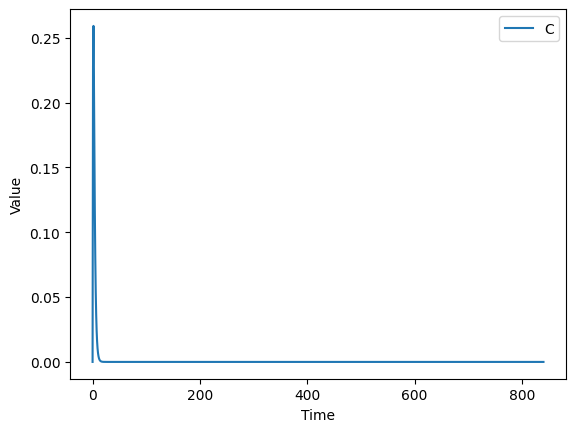

In [25]:
%%time
scipy_model = ScipyModel(model=filename)
scipy_model.update_constants(OralDose=50)
scipy_model.assign_forcing_function('OralExp', 'PerDose', t0=0, duration=scipy_model.parameters['OralDur'], period=7*24)
times = np.linspace(0, 35*24, 1000)
solution = scipy_model.run_model(times)
solution.plot_results(variables='C')

<Axes: xlabel='Time', ylabel='Input Value'>

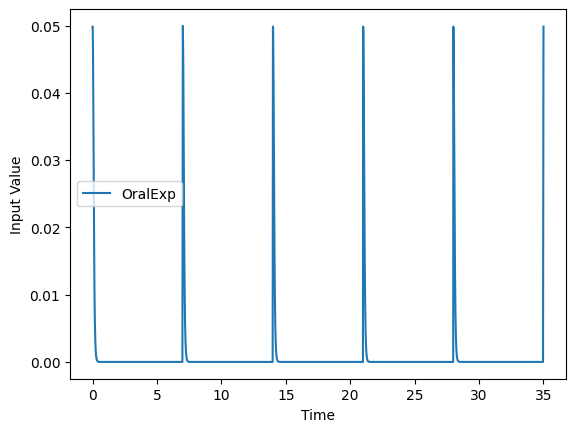

In [12]:
solution.plot_inputs(variables='OralExp')

# Jax

In [19]:
jax_model.forcing_functions

{}

CPU times: user 1.01 s, sys: 143 ms, total: 1.15 s
Wall time: 842 ms


<Axes: xlabel='Time', ylabel='Value'>

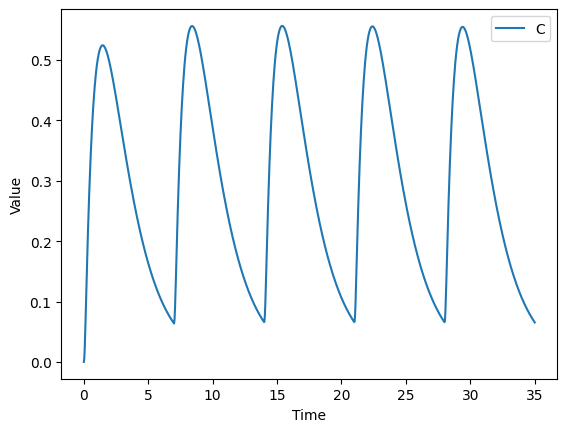

In [23]:
%%time
jax_model = JaxModel(model=filename)
#jax_model.update_Y0(A0=50.)
jax_model.update_constants(OralDose=100)
jax_model.assign_forcing_function('OralExp', 'PerDose', t0=0, duration=jax_model.parameters['OralDur'], period=7)
times = np.linspace(0, 35, 1000)
solution = jax_model.run_model(times)
solution.plot_results(variables='C')

<Axes: xlabel='Time', ylabel='Input Value'>

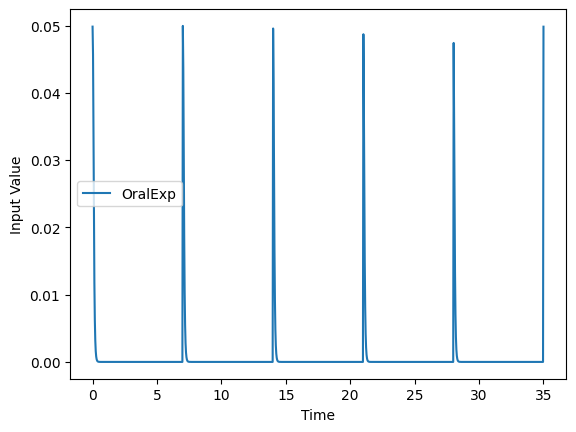

In [30]:
solution.plot_inputs(variables='OralExp')

CPU times: user 1.01 s, sys: 157 ms, total: 1.17 s
Wall time: 863 ms


<Axes: xlabel='Time', ylabel='Value'>

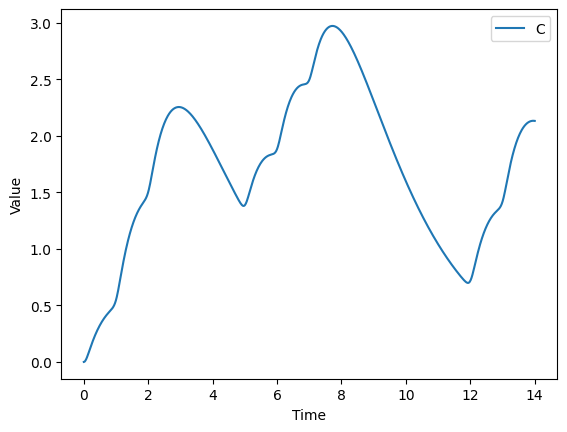

In [ ]:
%%time
jax_model = JaxModel(model=filename)
#jax_model.update_Y0(A0=50.)
jax_model.update_constants(OralDose=100)
jax_model.assign_forcing_function('OralExp', 'NDoses', t0_list=[0, 1, 2, 5, 6, 7, 12, 13], duration=jax_model.parameters['OralDur'])
times = np.linspace(0, 14, 1000)
solution = jax_model.run_model(times)
solution.plot_results(variables='C')

<Axes: xlabel='Time', ylabel='Input Value'>

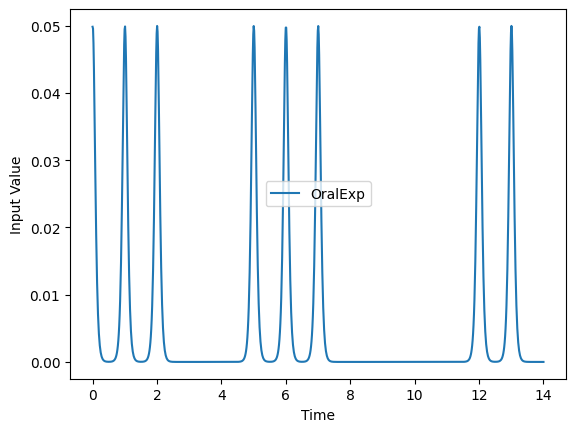

In [28]:
solution.plot_inputs(variables='OralExp')

In [14]:
jax_model.parameters['OralDur']

0.01

CPU times: user 1.03 s, sys: 145 ms, total: 1.17 s
Wall time: 870 ms


<Axes: xlabel='Time', ylabel='Value'>

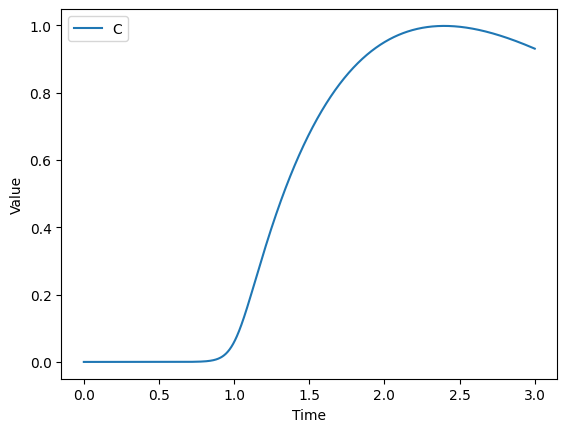

In [20]:
%%time
jax_model = JaxModel(model=filename)
#jax_model.update_Y0(A0=50.)
jax_model.update_constants(OralDose=100)
jax_model.assign_forcing_function('OralExp', 'NDoses', t0_list=[1], duration=jax_model.parameters['OralDur'])
times = np.linspace(0, 3, 1000)
solution = jax_model.run_model(times)
solution.plot_results(variables='C')

<Axes: xlabel='Time', ylabel='Input Value'>

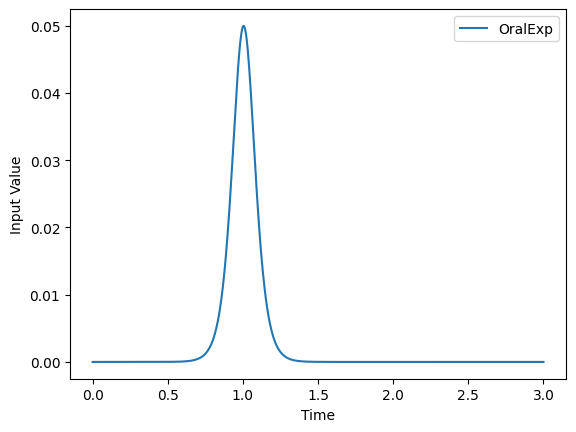

In [21]:
solution.plot_inputs(variables='OralExp')